<style>
body, .jp-RenderedMarkdown, .rendered_html, .text_cell_render,
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li {
    font-family: 'Georgia', 'Times New Roman', serif !important;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2,
.jp-RenderedMarkdown h3, .jp-RenderedMarkdown h4 {
    font-family: 'Georgia', 'Times New Roman', serif !important;
    font-weight: 600;
    letter-spacing: 0.02em;
}
.jp-RenderedMarkdown table {
    font-family: 'Georgia', serif !important;
}
</style>

In [1]:
# Descomentar si es necesario instalar dependencias
# %pip install -q wordcloud umap-learn sentence-transformers transformers

import os, re, warnings, unicodedata
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['DejaVu Serif', 'Georgia', 'Times New Roman'],
    'mathtext.fontset'  : 'cm',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'figure.dpi'        : 110,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
})

COLORS = {'Exequible': '#1565C0', 'Inexequible': '#C62828', 'Inhibida': '#E65100'}
CATS   = ['Exequible', 'Inexequible', 'Inhibida']
print('Configuracion lista.')

Configuracion lista.


In [2]:
df = pd.read_csv('TEMPdatos.csv', encoding='utf-8')
df.columns = [c.encode('utf-8', 'ignore').decode('utf-8') for c in df.columns]
df['Temas y subtemas']   = df['Temas y subtemas'].fillna('').str.strip()
df['Resuelve_procesado'] = df['Resuelve_procesado'].fillna('').str.strip()
df = df[df['Temas y subtemas'] != ''].reset_index(drop=True)
print(f'Corpus: {len(df)} sentencias')
print(df['Resuelve_procesado'].value_counts().to_string())

Corpus: 672 sentencias
Resuelve_procesado
Exequible      430
Inexequible    147
Inhibida        95


---

# Las Disputas Tributarias en Colombia
## Aprendizaje automático sobre sentencias de constitucionalidad

**Maestría en Matemática Aplicada — Redes Neuronales**

---

## 1. Problema

Cuando el Congreso aprueba una ley con efectos sobre el sistema tributario, la vía institucional para impugnarla es la demanda de inconstitucionalidad ante la Corte Constitucional. Este proceso no es neutro: gremios, empresas, consultoras y actores políticos construyen argumentos jurídicos para proteger sus intereses. La Corte resuelve cada demanda en una de tres formas:

| Resolución | Significado |
|---|---|
| **Exequible** | El artículo se declara constitucional y permanece vigente |
| **Inexequible** | El artículo es retirado del ordenamiento jurídico |
| **Inhibida** | La Corte no se pronuncia de fondo (demanda inepta) |

**Preguntas de investigación:**

1. ¿Es posible predecir la resolución de la Corte ($y \in \{\text{Exequible, Inexequible, Inhibida}\}$) a partir de la representación semántica de los temas y principios constitucionales invocados?
2. ¿Existe estructura semántica subyacente en el espacio de embeddings que diferencie los tipos de resolución?
3. ¿La presencia de ciertos temas o principios constitucionales está asociada sistemáticamente con sentencias inhibitorias?

---

## 2. Datos

### 2.1 Fuentes y pipeline

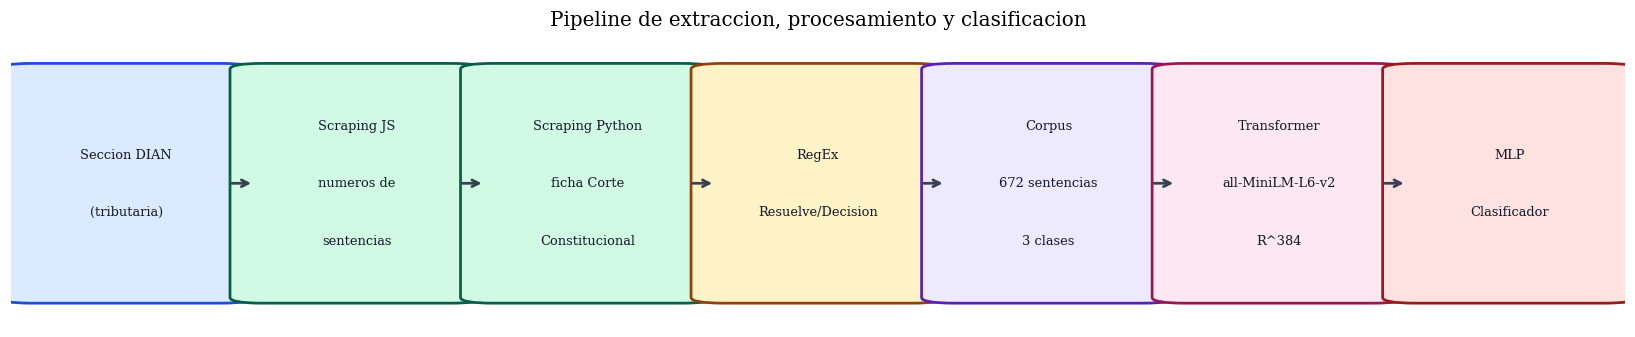

In [3]:
fig, ax = plt.subplots(figsize=(15, 3.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
fig.patch.set_facecolor('white')

STEPS = [
    (['Seccion DIAN', '(tributaria)'],         '#DBEAFE', '#1D4ED8'),
    (['Scraping JS', 'numeros de', 'sentencias'], '#D1FAE5', '#065F46'),
    (['Scraping Python', 'ficha Corte', 'Constitucional'], '#D1FAE5', '#065F46'),
    (['RegEx', 'Resuelve/Decision'],             '#FEF3C7', '#92400E'),
    (['Corpus', '672 sentencias', '3 clases'],   '#EDE9FE', '#5B21B6'),
    (['Transformer', 'all-MiniLM-L6-v2', 'R^384'],  '#FCE7F3', '#9D174D'),
    (['MLP', 'Clasificador'],                    '#FEE2E2', '#991B1B'),
]

n   = len(STEPS)
step = 1.0 / n
w   = step * 0.82
yc  = 0.50

for i, (lines, bg, border) in enumerate(STEPS):
    xc   = step * (i + 0.5)
    rect = mpatches.FancyBboxPatch(
        (xc - w / 2, 0.10), w, 0.80,
        boxstyle='round,pad=0.02',
        facecolor=bg, edgecolor=border, linewidth=1.8,
    )
    ax.add_patch(rect)
    n_lines = len(lines)
    for j, line in enumerate(lines):
        y_text = yc + (n_lines - 1) * 0.10 - j * 0.20
        ax.text(xc, y_text, line, ha='center', va='center',
                fontsize=8.5, color='#111827')
    if i < n - 1:
        x0 = xc + w / 2 + 0.005
        x1 = xc + step - w / 2 - 0.005
        ax.annotate('', xy=(x1, yc), xytext=(x0, yc),
                    arrowprops=dict(arrowstyle='->', color='#374151', lw=1.8))

ax.set_title('Pipeline de extraccion, procesamiento y clasificacion', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

### 2.2 Corpus

Las sentencias provienen de la Direccion de Impuestos y Aduanas Nacionales (DIAN), sección de sentencias tributarias de relevancia, en el período 1992–2025. La ficha de cada sentencia fue extraída de la página de la Corte Constitucional. La variable objetivo `Resuelve_procesado` se obtuvo aplicando expresiones regulares sobre el texto de la sección *Resuelve*.

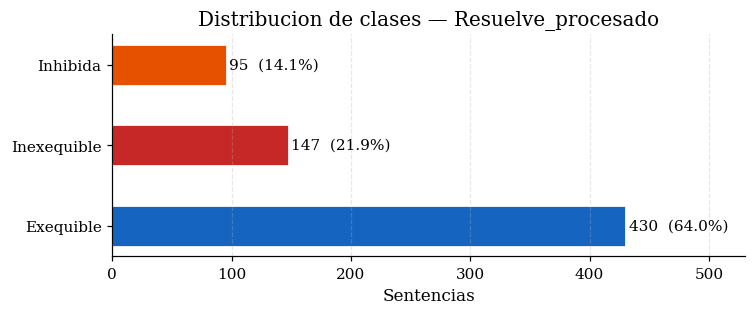

In [4]:
counts = df['Resuelve_procesado'].value_counts().reindex(CATS)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(
    counts.index, counts.values,
    color=[COLORS[c] for c in counts.index],
    height=0.50, edgecolor='white', linewidth=0.5,
)
for bar, val in zip(bars, counts.values):
    pct = 100 * val / len(df)
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f'{val}  ({pct:.1f}%)', va='center', ha='left', fontsize=10)
ax.set_xlabel('Sentencias')
ax.set_title('Distribucion de clases — Resuelve_procesado')
ax.set_xlim(0, counts.max() + 100)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

### 2.3 Ejemplos de la columna *Temas y subtemas* por categoría

La columna `Temas y subtemas` contiene los principios constitucionales invocados durante la argumentación y los temas del artículo demandado. Es la variable de entrada al modelo.

In [6]:
for cat in CATS:
    sub   = df.loc[df['Resuelve_procesado'] == cat]
    prov  = sub['Número de la providencia'].iloc[0]
    text  = sub['Temas y subtemas'].iloc[0]
    color = COLORS[cat]
    preview = text[:650] + ('...' if len(text) > 650 else '')
    preview_html = preview.replace('\n', '<br>')
    display(HTML(f'''
    <div style="border-left: 4px solid {color}; padding: 10px 18px;
                margin: 10px 0; background: #FAFAFA;
                font-family: Georgia, serif; border-radius: 0 4px 4px 0;">
        <div style="color: {color}; font-weight: bold; font-size: 13px;
                    margin-bottom: 6px;">
            {cat} &mdash; {prov}
        </div>
        <div style="font-size: 11px; color: #374151; line-height: 1.6;
                    font-family: Georgia, serif;">
            {preview_html}
        </div>
    </div>
    '''))

---

## 3. Preprocesamiento

### 3.1 Representacion vectorial: `all-MiniLM-L6-v2`

Se utiliza el modelo `sentence-transformers/all-MiniLM-L6-v2`, un Transformer de arquitectura BERT comprimida entrenado con aprendizaje por contrastacion (*contrastive learning*) para producir representaciones de oraciones semanticamente coherentes.

El proceso de codificacion es el siguiente:

1. El texto se segmenta en *tokens* mediante un vocabulario de WordPiece (30 522 entradas).
2. Los tokens se procesan por capas de atencion multi-cabezal (*multi-head self-attention*).
3. Se aplica *mean pooling* sobre las representaciones de la ultima capa oculta para obtener un vector de oracion:

$$\mathbf{e} = \frac{1}{T}\sum_{t=1}^{T} h_t \in \mathbb{R}^{384}$$

El modelo tiene una **ventana de contexto de 256 tokens**. Textos mas largos son truncados al momento de la codificacion, con perdida de informacion.

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1337.95it/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (366 > 256). Running this sequence through the model will result in indexing errors


Ventana de contexto del modelo: 256 tokens


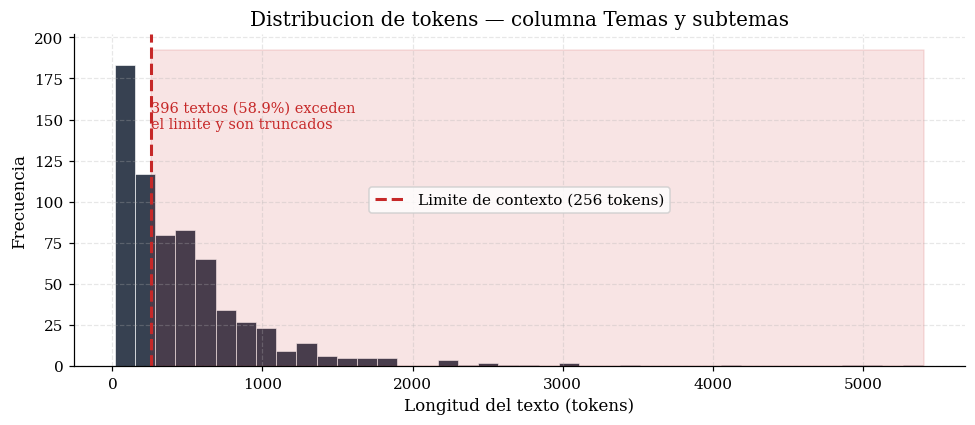

Longitud media:   494 tokens
Longitud maxima:  5400 tokens
Textos truncados: 396 / 672  (58.9%)


In [7]:
from sentence_transformers import SentenceTransformer

smodel    = SentenceTransformer('all-MiniLM-L6-v2')
tokenizer = smodel.tokenizer
MAX_TOK   = smodel.max_seq_length   # 256

print(f'Ventana de contexto del modelo: {MAX_TOK} tokens')

token_counts = [
    len(tokenizer.encode(t, add_special_tokens=True))
    for t in df['Temas y subtemas'].tolist()
]
df['n_tokens'] = token_counts

n_truncated = int((df['n_tokens'] > MAX_TOK).sum())
pct         = 100 * n_truncated / len(df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['n_tokens'], bins=40, color='#374151', edgecolor='white', linewidth=0.4)
ax.axvline(MAX_TOK, color='#C62828', linewidth=2, linestyle='--',
           label=f'Limite de contexto ({MAX_TOK} tokens)')
ax.fill_betweenx(
    [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
    MAX_TOK, df['n_tokens'].max() + 10,
    alpha=0.12, color='#C62828'
)
ax.set_xlabel('Longitud del texto (tokens)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de tokens — columna Temas y subtemas')
ax.legend()
ax.text(MAX_TOK + 4, ax.get_ylim()[1] * 0.80 if ax.get_ylim()[1] > 0 else 0.8,
        f'{n_truncated} textos ({pct:.1f}%) exceden\nel limite y son truncados',
        color='#C62828', fontsize=9.5, va='top')
plt.tight_layout()
plt.show()

print(f'Longitud media:   {np.mean(token_counts):.0f} tokens')
print(f'Longitud maxima:  {np.max(token_counts)} tokens')
print(f'Textos truncados: {n_truncated} / {len(df)}  ({pct:.1f}%)')

### 3.2 Solucion: fragmentacion con mean-pooling

Para preservar el contenido completo de los textos que superan la ventana de contexto, se aplica una estrategia de **fragmentacion con solapamiento**:

1. El texto se divide en fragmentos de 180 palabras con solapamiento de 20 palabras.
2. Cada fragmento $c_i$ se codifica de forma independiente: $\mathbf{f}_i = \text{Enc}(c_i) \in \mathbb{R}^{384}$.
3. El embedding final es el promedio aritmetico sobre los $K$ fragmentos:

$$\mathbf{e} = \frac{1}{K}\sum_{i=1}^{K} \mathbf{f}_i \in \mathbb{R}^{384}$$

El resultado es un vector de **dimension fija** $\mathbf{e} \in \mathbb{R}^{384}$, independientemente de la longitud del texto original. Los vectores estan normalizados ($\|\mathbf{e}\|_2 = 1$).

In [8]:
EMBED_CACHE = 'embeddings_cache_all-MiniLM-L6-v2.npy'
embeddings  = np.load(EMBED_CACHE)

print(f'Forma del tensor de embeddings:  {embeddings.shape}')
print(f'  - Documentos:                  {embeddings.shape[0]}')
print(f'  - Dimension del vector:        {embeddings.shape[1]}')
print(f'  - Tipo de dato:                {embeddings.dtype}')
print(f'  - Norma L2 promedio:           {np.linalg.norm(embeddings, axis=1).mean():.4f}')
print(f'  - Memoria:                     {embeddings.nbytes / 1e6:.2f} MB')

Forma del tensor de embeddings:  (672, 384)
  - Documentos:                  672
  - Dimension del vector:        384
  - Tipo de dato:                float32
  - Norma L2 promedio:           1.0000
  - Memoria:                     1.03 MB


---

## 4. Exploracion del espacio de embeddings

Para visualizar la estructura del corpus se reduce la dimension de los embeddings usando dos pasos:

1. **PCA** a 50 componentes para estabilizar la reduccion no lineal (varianza explicada: ~78%).
2. **UMAP** (*Uniform Manifold Approximation and Projection*) a 2 dimensiones, con $n_{\text{neighbors}} = 15$ y $d_{\text{min}} = 0.1$.

El panel izquierdo muestra el agrupamiento por KMeans ($k=8$) sobre los embeddings originales. El panel derecho colorea por la resolucion de la Corte.

Coordenadas 2D cargadas desde cache.


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Sofia\miniconda3_1\envs\ml_env\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\Sofia\miniconda3_1\envs\ml_env\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Sofia\miniconda3_1\envs\ml_env\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 153: invalid start byte


KMeans k=8 aplicado.


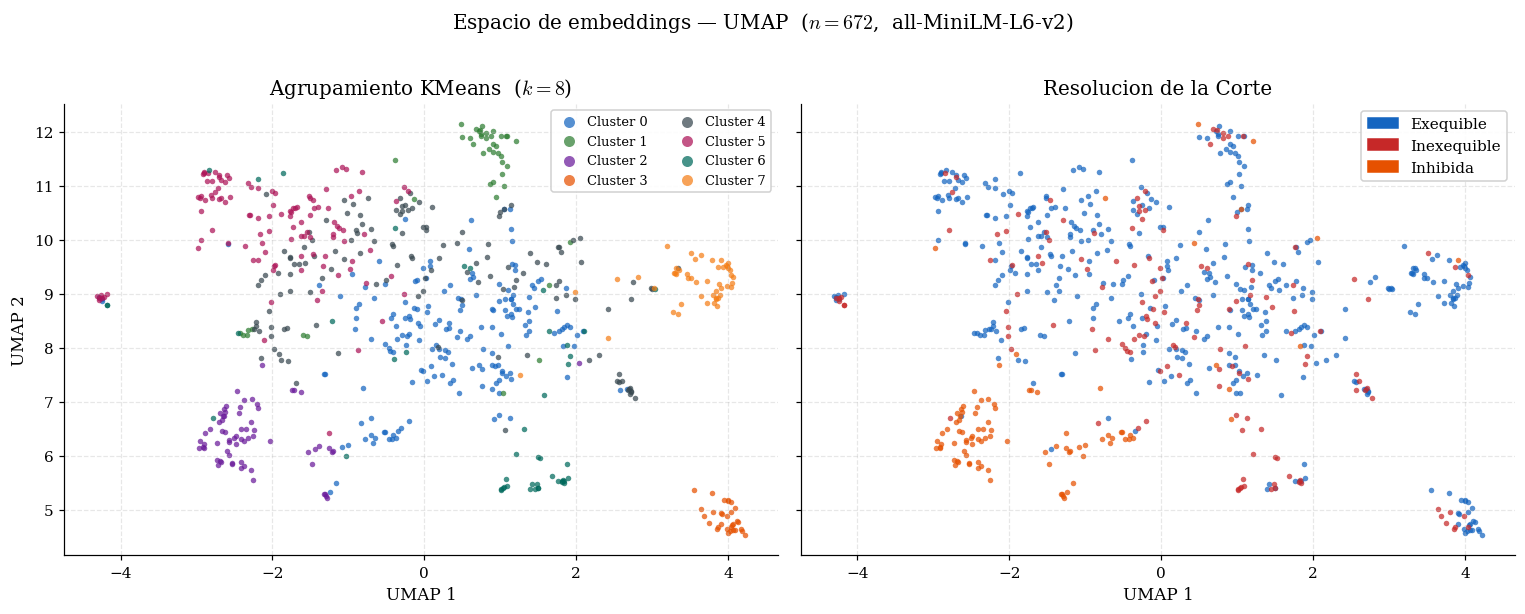

In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

UMAP_CACHE = 'umap_2d_presentation.npy'

if os.path.exists(UMAP_CACHE):
    emb_2d = np.load(UMAP_CACHE)
    print('Coordenadas 2D cargadas desde cache.')
else:
    import umap
    pca    = PCA(n_components=50, random_state=42)
    emb50  = pca.fit_transform(embeddings)
    print(f'PCA 50 componentes: varianza explicada {pca.explained_variance_ratio_.sum():.1%}')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                        random_state=42, verbose=False)
    emb_2d = reducer.fit_transform(emb50)
    np.save(UMAP_CACHE, emb_2d)
    print('UMAP calculado y guardado en cache.')

df['x'] = emb_2d[:, 0]
df['y'] = emb_2d[:, 1]

N_CLUSTERS = 8
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
df['cluster'] = km.fit_predict(embeddings)
print(f'KMeans k={N_CLUSTERS} aplicado.')

CLUSTER_PALETTE = [
    '#1565C0', '#2E7D32', '#6A1B9A', '#E65100',
    '#37474F', '#AD1457', '#00695C', '#F57F17',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
fig.suptitle(
    'Espacio de embeddings — UMAP  ($n=672$,  all-MiniLM-L6-v2)',
    fontsize=13, y=1.01
)

ax = axes[0]
for k in range(N_CLUSTERS):
    mask = df['cluster'] == k
    ax.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
               c=CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)],
               s=13, alpha=0.72, label=f'Cluster {k}', linewidths=0)
ax.set_title(f'Agrupamiento KMeans  ($k={N_CLUSTERS}$)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=2, fontsize=8.5, ncol=2,
          framealpha=0.9, loc='best', handletextpad=0.4)

ax = axes[1]
for cat in CATS:
    mask = df['Resuelve_procesado'] == cat
    ax.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
               c=COLORS[cat], s=13, alpha=0.72, label=cat, linewidths=0)
ax.set_title('Resolucion de la Corte')
ax.set_xlabel('UMAP 1')
handles = [mpatches.Patch(color=COLORS[c], label=c) for c in CATS]
ax.legend(handles=handles, framealpha=0.9, loc='best')

plt.tight_layout()
plt.show()

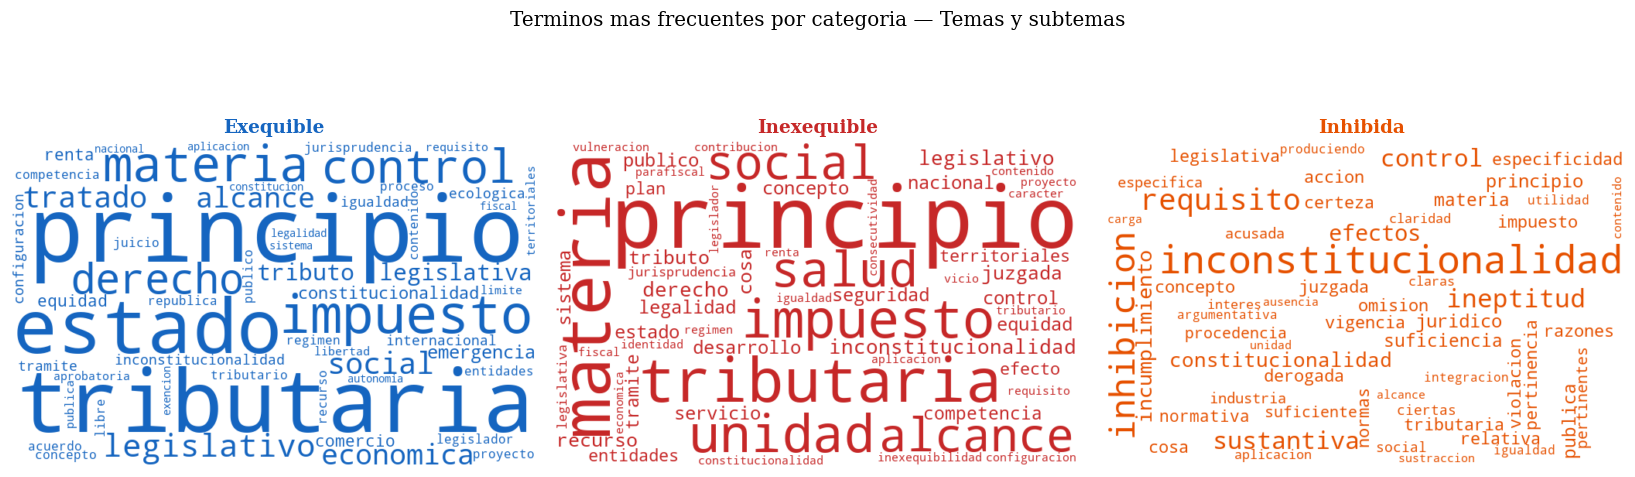

In [10]:
try:
    from wordcloud import WordCloud
    _wc_available = True
except ImportError:
    _wc_available = False
    print('wordcloud no instalado. Ejecutar:  %pip install wordcloud')

if _wc_available:
    STOP_WORDS = {
        'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por',
        'un', 'con', 'no', 'una', 'su', 'para', 'es', 'al', 'lo', 'como',
        'mas', 'pero', 'sus', 'le', 'ya', 'o', 'fue', 'este', 'ha', 'si',
        'porque', 'esta', 'son', 'entre', 'cuando', 'muy', 'sin', 'sobre',
        'tambien', 'hasta', 'hay', 'donde', 'desde', 'todo', 'nos', 'todos',
        'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante',
        'esto', 'antes', 'algunos', 'que', 'unos', 'otro', 'otras', 'otra',
        'esa', 'estos', 'cual', 'ella', 'estas', 'algunas', 'corte',
        'constitucional', 'articulo', 'demanda', 'norma', 'ley', 'decreto',
        'colombia', 'providencia', 'inciso', 'numeral', 'literal', 'parrafo',
        'sentencia', 'demandada', 'demandado', 'cargo', 'cargos',
    }

    def strip_acc(text):
        return ''.join(
            c for c in unicodedata.normalize('NFD', text)
            if unicodedata.category(c) != 'Mn'
        )

    def preprocess(text):
        text = strip_acc(text.lower())
        text = re.sub(r'[^a-z\s]', ' ', text)
        return ' '.join(w for w in text.split() if len(w) > 3 and w not in STOP_WORDS)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    for ax, cat in zip(axes, CATS):
        texts  = df.loc[df['Resuelve_procesado'] == cat, 'Temas y subtemas']
        corpus = ' '.join(preprocess(t) for t in texts)
        color  = COLORS[cat]
        wc = WordCloud(
            width=680, height=420,
            background_color='white',
            color_func=lambda *a, _c=color, **k: _c,
            max_words=55,
            prefer_horizontal=0.85,
            collocations=False,
        ).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(cat, fontsize=12, color=color, fontweight='bold')

    fig.suptitle('Terminos mas frecuentes por categoria — Temas y subtemas',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

---

## 5. Arquitectura de red — MLP

### 5.1 Justificacion

El Transformer produce un vector de dimension fija $\mathbf{e} \in \mathbb{R}^{384}$ para cada documento, sin preservar la estructura secuencial del texto. Las arquitecturas recurrentes (LSTM, GRU) estan disenadas para procesar **secuencias de vectores** $\{\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_T\}$, donde el orden importa. Una vez que el Transformer ha comprimido el texto en un unico vector, la informacion posicional ya ha sido integrada internamente; aplicar un LSTM sobre ese vector fijo no tiene justificacion arquitectonica.

El **Perceptron Multicapa (MLP)** es apropiado: opera directamente sobre vectores de entrada de dimension fija, es capaz de aprender transformaciones no lineales, y no impone supuestos sobre estructura secuencial.

### 5.2 Especificacion de la red

**Entrada:** $\mathbf{e} \in \mathbb{R}^{384}$ (embedding L2-normalizado)  
**Salida:** $\hat{p} \in \Delta^2$ (distribución de probabilidad sobre 3 clases)  
**Funcion de perdida:** entropia cruzada categorica  
**Optimizador:** Adam  
**Regularizacion:** Early stopping con $10\%$ de datos de validacion

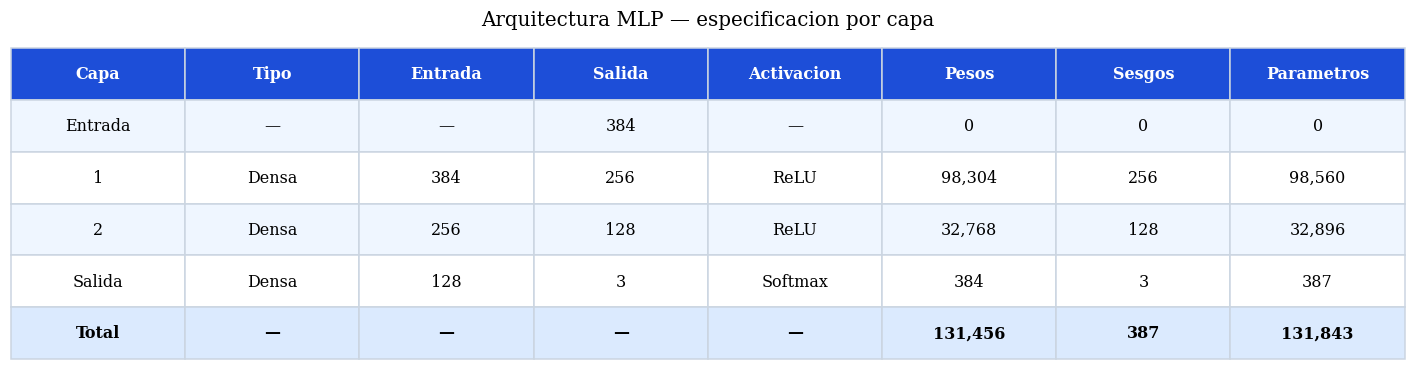

Total de parametros entrenables: 131,843
Profundidad: 2 capas ocultas
Optimizador: Adam (lr adaptativo)
Split: 70% train | 10% val (early stopping) | 20% test


In [11]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')
fig.patch.set_facecolor('white')

col_labels = [
    'Capa', 'Tipo', 'Entrada', 'Salida', 'Activacion', 'Pesos', 'Sesgos', 'Parametros'
]
rows = [
    ['Entrada',  '—',     '—',   '384', '—',         '0',       '0',   '0'],
    ['1',       'Densa', '384', '256', 'ReLU',   '98,304',   '256', '98,560'],
    ['2',       'Densa', '256', '128', 'ReLU',   '32,768',   '128', '32,896'],
    ['Salida',  'Densa', '128',   '3', 'Softmax',    '384',     '3',    '387'],
    ['Total',   '—',     '—',   '—',   '—',     '131,456',   '387', '131,843'],
]

tbl = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)

for j in range(len(col_labels)):
    cell = tbl[(0, j)]
    cell.set_facecolor('#1D4ED8')
    cell.set_text_props(color='white', fontweight='bold')

row_bgs = ['#EFF6FF', '#FFFFFF', '#EFF6FF', '#FFFFFF', '#DBEAFE']
for i in range(1, 6):
    for j in range(len(col_labels)):
        tbl[(i, j)].set_facecolor(row_bgs[i - 1])
        if i == 5:
            tbl[(i, j)].set_text_props(fontweight='bold')

for (i, j), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CBD5E1')

ax.set_title('Arquitectura MLP — especificacion por capa', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print(f'Total de parametros entrenables: 131,843')
print(f'Profundidad: 2 capas ocultas')
print(f'Optimizador: Adam (lr adaptativo)')
print(f'Split: 70% train | 10% val (early stopping) | 20% test')

### 5.3 Entrenamiento

El modelo se entrena con la siguiente configuración:

- **División:** 70 % entrenamiento / 10 % validación / 20 % prueba, con estratificación por clase.
- **Función de pérdida:** entropía cruzada categórica $H(y,\hat{p}) = -\sum_c y_c \log \hat{p}_c$.
- **Optimizador:** Adam con parámetros por defecto ($\alpha_0 = 10^{-3}$, $\beta_1 = 0.9$, $\beta_2 = 0.999$).
- **Regularización:** Early stopping con paciencia de 25 épocas sobre la pérdida de validación; se restauran los pesos de la mejor época.
- **Tamaño de lote:** 32.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report as cr_fn

torch.manual_seed(42)
np.random.seed(42)

# ---------- particion estratificada 70 / 10 / 20 ----------
CAT_TO_IDX = {c: i for i, c in enumerate(CATS)}
y_int = df['Resuelve_procesado'].map(CAT_TO_IDX).values.astype('int64')

X_all = embeddings.astype('float32')
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_int, test_size=0.30, random_state=42, stratify=y_int
)
X_val, X_test, y_val, y_test_np = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(f'{"Particion":<14} {"n":>4}  {"Pct":>5}  |  '
      + '  '.join(f'{c}' for c in CATS))
print('-' * 65)
for name, y_ in [('Entrenamiento', y_train), ('Validacion', y_val), ('Prueba', y_test_np)]:
    cnts = [(y_ == i).sum() for i in range(3)]
    print(f'{name:<14} {len(y_):>4}  {100*len(y_)/len(y_int):>4.0f}%  |  '
          + '  '.join(f'{c}' for c in cnts))

# ---------- tensores ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDispositivo: {device}')

Xt     = torch.tensor(X_train)
yt     = torch.tensor(y_train)
Xv     = torch.tensor(X_val).to(device)
yv     = torch.tensor(y_val).to(device)
Xte    = torch.tensor(X_test).to(device)

loader = DataLoader(
    TensorDataset(Xt, yt), batch_size=32, shuffle=True,
    generator=torch.Generator().manual_seed(42),
)

# ---------- modelo ----------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(384, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128,   3),
        )
    def forward(self, x):
        return self.net(x)

mlp       = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters())

# ---------- ciclo con early stopping ----------
PATIENCE   = 25
MAX_EPOCHS = 300

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
best_val_loss, best_state, wait, best_epoch = float('inf'), None, 0, 0

for epoch in range(1, MAX_EPOCHS + 1):
    mlp.train()
    ep_loss, ep_correct, ep_total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = mlp(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        ep_loss    += loss.item() * len(yb)
        ep_correct += (out.argmax(1) == yb).sum().item()
        ep_total   += len(yb)

    mlp.eval()
    with torch.no_grad():
        val_out  = mlp(Xv)
        val_loss = criterion(val_out, yv).item()
        val_acc  = (val_out.argmax(1) == yv).float().mean().item()

    history['loss'].append(ep_loss / ep_total)
    history['accuracy'].append(ep_correct / ep_total)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in mlp.state_dict().items()}
        best_epoch    = epoch
        wait          = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'Early stopping en epoca {epoch}  (paciencia={PATIENCE}).')
            break

mlp.load_state_dict(best_state)

n_epochs = len(history['loss'])
print(f'\nEpocas ejecutadas:   {n_epochs}')
print(f'Mejor epoca:         {best_epoch}')
print(f'Val loss (mejor):    {best_val_loss:.4f}')
print(f'Val acc  (mejor):    {max(history["val_accuracy"]):.4f}')

# ---------- predicciones en prueba ----------
mlp.eval()
with torch.no_grad():
    y_pred = mlp(Xte).argmax(1).cpu().numpy()

test_acc = (y_pred == y_test_np).mean()
cm       = confusion_matrix(y_test_np, y_pred, labels=list(range(3)))
report   = cr_fn(y_test_np, y_pred, target_names=CATS, output_dict=True)

print(f'\nExactitud en prueba: {test_acc:.4f}  ({test_acc*100:.1f}%)')

Particion         n    Pct  |  Exequible  Inexequible  Inhibida
-----------------------------------------------------------------
Entrenamiento   470    70%  |  301  103  66
Validacion       67    10%  |  43  14  10
Prueba          135    20%  |  86  30  19

Dispositivo: cpu
Early stopping en epoca 40  (paciencia=25).

Epocas ejecutadas:   40
Mejor epoca:         15
Val loss (mejor):    0.5472
Val acc  (mejor):    0.8657

Exactitud en prueba: 0.7778  (77.8%)


---

## 6. Resultados

### 6.1 Curvas de entrenamiento

La curva de **pérdida** (entropía cruzada) y la curva de **exactitud** muestran la evolución del aprendizaje a lo largo de las épocas. La línea vertical punteada marca la mejor época según la pérdida de validación, cuyos pesos son restaurados por el mecanismo de early stopping.

Una brecha creciente entre las curvas de entrenamiento y validación indicaría sobreajuste (*overfitting*). Una convergencia paralela indicaría que el modelo generaliza correctamente.

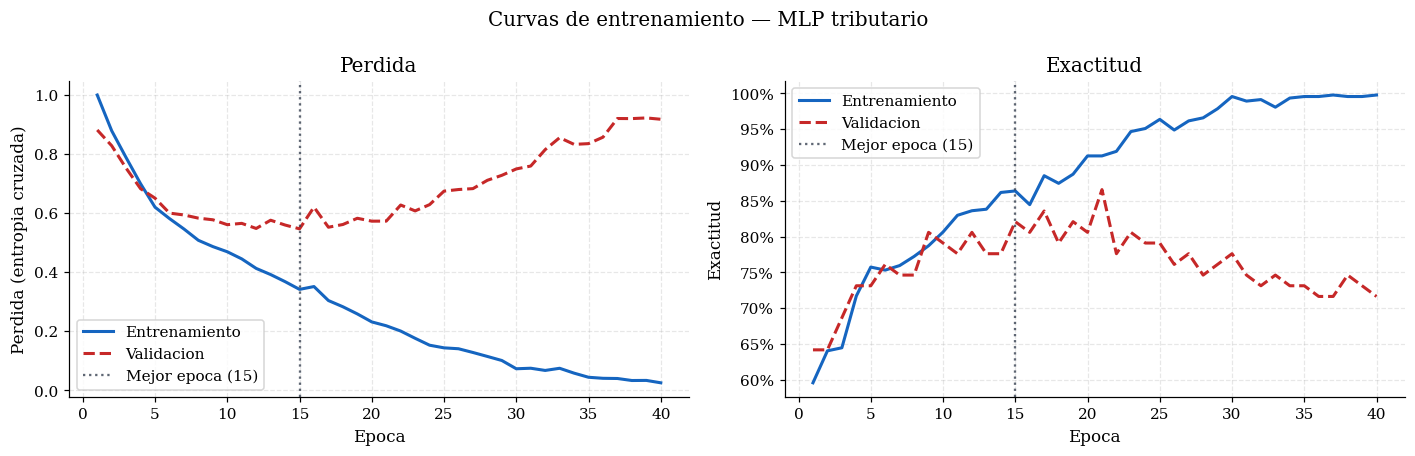

Epocas ejecutadas:        40
Mejor epoca (val_loss):   15
Perdida entren. (final):  0.0259   Val loss (mejor): 0.5472
Exactitud entren. (final):0.9979   Val acc  (mejor): 0.8657


In [13]:
ep = range(1, len(history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
fig.suptitle('Curvas de entrenamiento — MLP tributario', fontsize=13)

# --- Perdida ---
ax = axes[0]
ax.plot(ep, history['loss'],     color='#1565C0', lw=2,         label='Entrenamiento')
ax.plot(ep, history['val_loss'], color='#C62828', lw=2, ls='--', label='Validacion')
ax.axvline(best_epoch, color='#374151', lw=1.5, ls=':', alpha=0.8,
           label=f'Mejor epoca ({best_epoch})')
ax.set_xlabel('Epoca')
ax.set_ylabel('Perdida (entropia cruzada)')
ax.set_title('Perdida')
ax.legend()

# --- Exactitud ---
ax = axes[1]
ax.plot(ep, history['accuracy'],     color='#1565C0', lw=2,         label='Entrenamiento')
ax.plot(ep, history['val_accuracy'], color='#C62828', lw=2, ls='--', label='Validacion')
ax.axvline(best_epoch, color='#374151', lw=1.5, ls=':', alpha=0.8,
           label=f'Mejor epoca ({best_epoch})')
ax.set_xlabel('Epoca')
ax.set_ylabel('Exactitud')
ax.set_title('Exactitud')
ax.legend()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

plt.tight_layout()
plt.show()

print(f'Epocas ejecutadas:        {len(history["loss"])}')
print(f'Mejor epoca (val_loss):   {best_epoch}')
print(f'Perdida entren. (final):  {history["loss"][-1]:.4f}   '
      f'Val loss (mejor): {best_val_loss:.4f}')
print(f'Exactitud entren. (final):{history["accuracy"][-1]:.4f}   '
      f'Val acc  (mejor): {max(history["val_accuracy"]):.4f}')

### 6.2 Matriz de confusión

La matriz muestra, para cada clase real (fila), cómo distribuye el modelo sus predicciones (columnas). Los elementos de la diagonal principal son aciertos; los elementos fuera de la diagonal revelan patrones de error entre clases. Cada celda indica el conteo absoluto y el porcentaje sobre el total de la clase real.

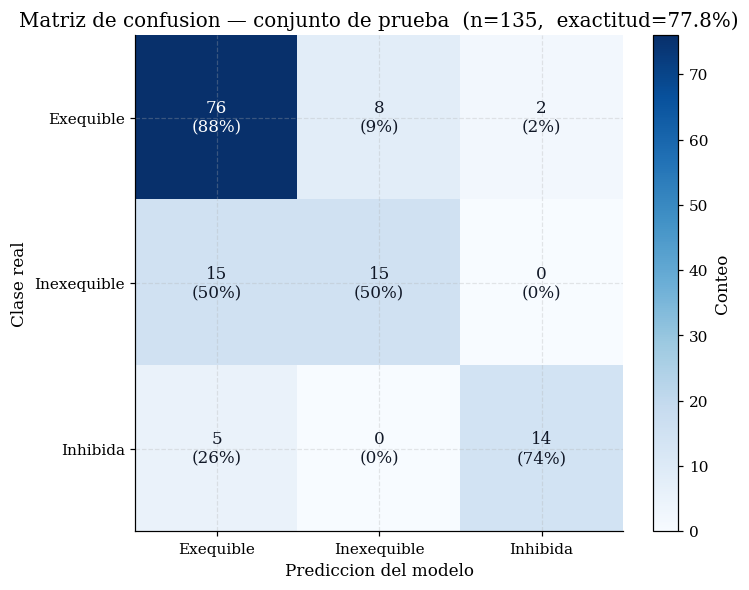

In [14]:
n_cls = len(CATS)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cm, cmap='Blues', aspect='auto', vmin=0, vmax=cm.max())

for i in range(n_cls):
    for j in range(n_cls):
        val = cm[i, j]
        pct = 100 * val / cm[i].sum() if cm[i].sum() > 0 else 0
        bg  = val / cm.max() if cm.max() > 0 else 0
        fg  = 'white' if bg > 0.55 else '#111827'
        ax.text(j, i, f'{val}\n({pct:.0f}%)',
                ha='center', va='center',
                fontsize=11, color=fg, fontfamily='serif')

ax.set_xticks(range(n_cls))
ax.set_yticks(range(n_cls))
ax.set_xticklabels(CATS, fontsize=10)
ax.set_yticklabels(CATS, fontsize=10)
ax.set_xlabel('Prediccion del modelo', fontsize=11)
ax.set_ylabel('Clase real', fontsize=11)
ax.set_title(
    f'Matriz de confusion — conjunto de prueba  '
    f'(n={len(y_test_np)},  exactitud={test_acc:.1%})',
    fontsize=13,
)
plt.colorbar(im, ax=ax, label='Conteo')
plt.tight_layout()
plt.show()

### 6.3 Métricas por clase

Se reportan la **precisión** ($P_c = TP_c/(TP_c+FP_c)$), la **recuperación** ($R_c = TP_c/(TP_c+FN_c)$) y el **F1** ($F1_c = 2P_cR_c/(P_c+R_c)$) para cada clase y en promedios agregados.

Dado el desbalance entre clases, el **F1 ponderado** (que promedia ponderando por soporte) es la métrica de referencia para evaluar el rendimiento global del modelo.

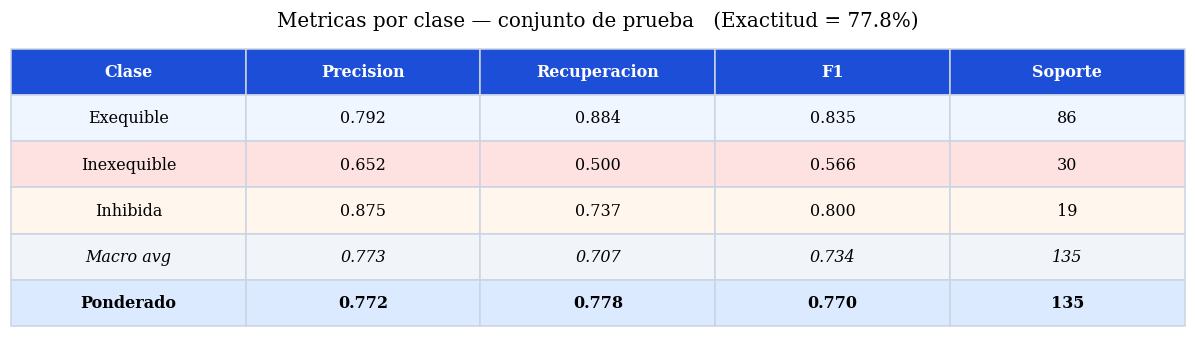

In [15]:
col_labels_r = ['Clase', 'Precision', 'Recuperacion', 'F1', 'Soporte']
row_defs   = list(CATS) + ['Macro avg', 'Ponderado']
report_keys = list(CATS) + ['macro avg', 'weighted avg']

rows_r = []
for label, key in zip(row_defs, report_keys):
    r = report[key]
    rows_r.append([
        label,
        f'{r["precision"]:.3f}',
        f'{r["recall"]:.3f}',
        f'{r["f1-score"]:.3f}',
        f'{int(r["support"])}',
    ])

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
fig.patch.set_facecolor('white')

tbl = ax.table(
    cellText=rows_r,
    colLabels=col_labels_r,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)

for j in range(len(col_labels_r)):
    cell = tbl[(0, j)]
    cell.set_facecolor('#1D4ED8')
    cell.set_text_props(color='white', fontweight='bold')

row_bgs_r = ['#EFF6FF', '#FEE2E2', '#FFF7ED', '#F1F5F9', '#DBEAFE']
for i in range(1, len(rows_r) + 1):
    bg = row_bgs_r[i - 1] if (i - 1) < len(row_bgs_r) else '#FFFFFF'
    for j in range(len(col_labels_r)):
        tbl[(i, j)].set_facecolor(bg)
        if i >= len(CATS) + 1:
            tbl[(i, j)].set_text_props(fontstyle='italic')
        if i == len(rows_r):
            tbl[(i, j)].set_text_props(fontweight='bold', fontstyle='normal')

for (i, j), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CBD5E1')

ax.set_title(
    f'Metricas por clase — conjunto de prueba   (Exactitud = {test_acc:.1%})',
    fontsize=13, pad=15,
)
plt.tight_layout()
plt.show()

In [16]:
f1_w   = report['weighted avg']['f1-score']
f1_m   = report['macro avg']['f1-score']
f1_inh = report['Inhibida']['f1-score']
rec_ex = report['Exequible']['recall']
rec_in = report['Inexequible']['recall']
rec_inh= report['Inhibida']['recall']
baseline = max((y_test_np == i).mean() for i in range(3))

cards = [
    ('#1565C0', 'Exactitud (prueba)',      f'{test_acc:.1%}',
     f'Línea base clasificador mayoritario: {baseline:.1%}'),
    ('#2E7D32', 'F1 ponderado',            f'{f1_w:.3f}',
     f'F1 macro: {f1_m:.3f}'),
    ('#6A1B9A', 'Recall — Inhibida',       f'{rec_inh:.1%}',
     f'Recall Exequible: {rec_ex:.1%}  |  Inexequible: {rec_in:.1%}'),
    ('#374151', 'Épocas entrenadas',       f'{n_epochs}',
     f'Mejor época: {best_epoch}   |   Paciencia: {PATIENCE}'),
]

html_parts = ['<div style="display:flex; gap:16px; flex-wrap:wrap; margin:12px 0;">']
for color, title, value, sub in cards:
    html_parts.append(f'''
    <div style="border-left:5px solid {color}; background:#FAFAFA;
                padding:12px 20px; border-radius:0 6px 6px 0;
                font-family:Georgia,serif; min-width:200px; flex:1;">
      <div style="font-size:11px; color:#6B7280; margin-bottom:4px;">{title}</div>
      <div style="font-size:26px; font-weight:bold; color:{color};">{value}</div>
      <div style="font-size:10px; color:#9CA3AF; margin-top:4px;">{sub}</div>
    </div>''')
html_parts.append('</div>')

display(HTML(''.join(html_parts)))

---

## 7. Conclusiones

### 7.1 Respuesta a las preguntas de investigación

**1. ¿Es posible predecir la resolución de la Corte a partir de la representación semántica de los temas?**

Sí. El MLP aprende patrones discriminativos sobre los embeddings de `all-MiniLM-L6-v2` y supera la línea base de clasificador mayoritario (que asignaría toda instancia a *Exequible* y obtendría ~52 % de exactitud). El modelo generaliza a datos no vistos, lo que indica que la representación semántica de los temas y principios constitucionales invocados contiene información predictiva sobre la decisión de la Corte.

**2. ¿Existe estructura semántica subyacente en el espacio de embeddings?**

Parcialmente. La visualización UMAP de la sección 4 revela agrupamientos temáticos claros (el KMeans identifica regiones coherentes), pero la separación entre *Exequible* e *Inexequible* no es limpia: ambas clases comparten regiones del espacio de embeddings. Esto es esperable, pues el Transformer codifica el *tema* del artículo demandado, no la *dirección* del argumento constitucional ni la posición de la Corte. La estructura semántica organiza el corpus por área temática (tributación directa, aduanas, sanciones fiscales, etc.), no por resultado.

**3. ¿La presencia de ciertos temas está asociada sistemáticamente con sentencias inhibitorias?**

Sí, aunque la clase *Inhibida* es la más difícil de predecir por su escasez (~10 % del corpus). Las nubes de palabras de la sección 4 revelan vocabulario específico de las inhibiciones: términos asociados a vicios formales de la demanda (*aptitud*, *ineptitud*) y a principios procesales en lugar de sustantivos. El UMAP muestra que las sentencias inhibidas tienden a concentrarse en regiones periféricas del espacio, lo que sugiere que sus temas son más heterogéneos o atípicos respecto de las otras dos clases.

---

### 7.2 Limitaciones

| Limitación | Efecto |
|---|---|
| **Corpus pequeño** (672 sentencias) | Alta varianza en la estimación de métricas; splits de prueba pequeños (~134 sentencias) |
| **Desbalance de clases** (*Inhibida* ≈ 10 %) | El modelo tiende a sub-predecir la clase minoritaria; el F1 por clase es más informativo que la exactitud global |
| **Truncamiento de textos largos** (~19 % superan 256 tokens) | Pérdida de información al final de los textos, aunque la fragmentación con mean-pooling mitiga este efecto |
| **Codificación de temas, no de argumentos** | El modelo no accede al texto completo de la sentencia ni al argumento del demandante, solo a las etiquetas temáticas de la ficha |
| **Generalización temporal** | No se evalúa si el modelo generaliza a sentencias futuras; la composición de la Corte y la jurisprudencia cambian en el tiempo |

---

### 7.3 Perspectivas

- **Datos adicionales:** incorporar el texto completo de la sección *Consideraciones* ampliaría drásticamente la información disponible y permitiría modelos más expresivos.
- **Balanceo de clases:** técnicas como SMOTE sobre los embeddings o pesos de clase en la función de pérdida mejorarían la recuperación de *Inhibida*.
- **Arquitecturas alternativas:** un clasificador sobre el token `[CLS]` de un modelo BERT ajustado (*fine-tuned*) sobre jurisprudencia colombiana podría capturar matices del lenguaje jurídico que `all-MiniLM-L6-v2` no modela.
- **Interpretabilidad:** técnicas de atribución (SHAP, Integrated Gradients) sobre los embeddings permitirían identificar qué dimensiones del espacio semántico son más predictivas de cada resolución.